# Laboratorio 4, Parte 2 — Preparación de datos para Machine Learning

**Universidad del Valle de Guatemala — CC3084 Data Science**
Lagos de **Atitlán** y **Amatitlán** · **Sentinel-2 L1C**

Este cuaderno cubre los **Ejercicios 1, 2 y 3** del enunciado. **No entrena modelos**:
eso corresponde a los Ejercicios 4–10.

---

## Aviso sobre la versión anterior

La primera versión de este cuaderno generaba **píxeles sintéticos** con un modo
demostrativo, porque en ese momento no existían rásteres descargados. Aquellos resultados
no eran observaciones satelitales.

Esta versión trabaja **exclusivamente con el dataset real** construido a partir de los
**22 GeoTIFF Sentinel-2 L1C** validados en la Parte 1. El generador sintético fue
**eliminado del flujo principal**: si falta el dataset, el cuaderno se detiene con un
error explícito.

| Cambio | Detalle |
|---|---|
| Datos | 22 escenas reales, sin ningún *fallback* sintético |
| Respuesta principal | **8 µg/L** (antes 50 µg/L, elegido sin respaldo bibliográfico) |
| Referencia corregida | Se eliminó una cita cuyo DOI correspondía a otro artículo |
| Variables nuevas | `year`, `month`, `season`, `spatial_block_1km` para validación agrupada |
| Viabilidad | Analizada por lago, fecha y bloque espacial, no solo por conteo global |


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()                      # ejecutar desde la raíz del repositorio
P2 = ROOT / "outputs" / "parte2"
DATA, TARGET, EDA, REPORTS = P2 / "data", P2 / "target", P2 / "eda", P2 / "reports"

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

if not (DATA / "dataset_manifest.csv").exists():
    raise FileNotFoundError(
        "No existe el dataset real. Ejecute primero:\n"
        "  python preparar_dataset_ml.py --build\n"
        "NO se genera ningún sustituto sintético.")

from preparar_dataset_ml import (
    TARGET_COLUMN, TARGET_THRESHOLD_UG_L, UMBRALES_CANDIDATOS,
    PREDICTORES_PRINCIPALES, EXCLUIDAS_POR_FUGA, COLUMNAS_AUXILIARES,
    COLUMNAS_TRAZABILIDAD, SIGNIFICADO_UMBRAL, DATASET_VERSION,
    BLOQUE_ESPACIAL_M, CALIB_MIN, CALIB_MAX, hash_esquema,
)

print("Directorio de trabajo :", ROOT)
print("Versión del dataset   :", DATASET_VERSION, "| hash de esquema:", hash_esquema())
print("Respuesta principal   :", TARGET_COLUMN, f"(>= {TARGET_THRESHOLD_UG_L:.0f} µg/L)")
print("Semilla               :", SEED)

Directorio de trabajo : C:\Users\mjyee\Downloads\DataScience\lab4data
Versión del dataset   : 2.0 | hash de esquema: 65825179def16792
Respuesta principal   : high_cyano_8 (>= 8 µg/L)
Semilla               : 42


---

# Ejercicio 1. Preparación de los datos para Machine Learning

## 1.1 Construcción del conjunto de datos por píxel

Cada fila representa **una observación geográfica válida dentro de un lago**: un píxel de
20 × 20 m (0.04 ha) clasificado como agua en una fecha concreta.

El proceso, implementado en `preparar_dataset_ml.py`, es:

1. Leer cada GeoTIFF real (9 bandas, EPSG:32615, 20 m).
2. Convertir los números digitales a **reflectancia** (× 0.0001, una sola vez).
3. Calcular NDVI, NDWI, NDCI, FAI y clorofila-a con el algoritmo de CyanoLakes.
4. Aplicar la **máscara de agua WBI** y los filtros de validez.
5. Derivar las coordenadas de cada píxel desde la **transformación afín real**.
6. Guardar en Parquet particionado por lago y fecha.


In [2]:
manifiesto = pd.read_csv(DATA / "dataset_manifest.csv")
print(f"Particiones: {len(manifiesto)}")
print(f"Filas totales: {manifiesto['filas'].sum():,}")
display(manifiesto.head(4))

diag = pd.read_csv(DATA / "limpieza_diagnostico.csv")
print(f"\nÁrea por píxel: 20 m x 20 m = 400 m² = 0.04 ha")

Particiones: 22
Filas totales: 3,756,510


,lake,date,filas,estado,dataset_version,schema_hash,archivo
0,Amatitlan,2025-01-28,36550,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
1,Amatitlan,2025-04-15,36184,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
2,Amatitlan,2025-04-28,36184,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...
3,Amatitlan,2025-11-24,36434,reutilizado,2.0,65825179def16792,outputs\parte2\data\pixels\lake=Amatitlan\date...



Área por píxel: 20 m x 20 m = 400 m² = 0.04 ha


## 1.2 Variables incluidas

El enunciado exige como mínimo: coordenadas, fecha, lago, bandas espectrales, NDVI, NDWI e
índice de cianobacteria. El dataset incluye todo eso más variables auxiliares para la
validación.


In [3]:
esquema = pd.read_csv(DATA / "dataset_schema.csv")
print(f"Total de variables: {len(esquema)}\n")
for rol, g in esquema.groupby("rol"):
    print(f"{rol} ({len(g)}): {', '.join(g['variable'])}")

display(esquema[["variable", "tipo", "rol", "faltantes_pct"]])

Total de variables: 31

auxiliar_validacion (4): year, month, season, spatial_block_1km
excluida_por_fuga (15): lake, date, row, col, x_utm, y_utm, longitude, latitude, B04, B05, NDVI, NDCI, FAI, chlorophyll, fuera_calibracion
predictor_principal (8): B02, B03, B07, B08, B8A, B11, B12, NDWI
respuesta_principal (1): high_cyano_8
respuesta_sensibilidad (3): high_cyano_20, high_cyano_25, high_cyano_50


,variable,tipo,rol,faltantes_pct
0,lake,category,excluida_por_fuga,0.0
1,date,category,excluida_por_fuga,0.0
2,row,int32,excluida_por_fuga,0.0
3,col,int32,excluida_por_fuga,0.0
4,x_utm,float64,excluida_por_fuga,0.0
5,y_utm,float64,excluida_por_fuga,0.0
6,longitude,float64,excluida_por_fuga,0.0
7,latitude,float64,excluida_por_fuga,0.0
8,B02,float32,predictor_principal,0.0
9,B03,float32,predictor_principal,0.0


### Variables auxiliares para validación

Se derivan del propio dataset y **no son predictores**; sirven para agrupar y estratificar:

- **`year`, `month`, `season`** — validación temporal. La estación se codifica según el
  régimen de Guatemala: seca de noviembre a abril, lluviosa de mayo a octubre.
- **`spatial_block_1km`** — cuadrícula de **1 000 m** derivada de las coordenadas UTM
  (EPSG:32615): `floor(x_utm/1000)` y `floor(y_utm/1000)`. El identificador incluye el
  nombre del lago para que dos lagos nunca compartan bloque. Es la variable de agrupación
  para `GroupKFold` en el Ejercicio 6.


## 1.3 Limpieza aplicada

Se eliminaron del conjunto de análisis las observaciones que no representan agua válida:


In [4]:
criterios = [
    ("descartados_nodata", "NoData / -9999 / fuera de datos válidos"),
    ("descartados_no_finitos", "NaN o infinitos"),
    ("descartados_reflectancia_no_positiva", "Reflectancia TOA <= 0 (no física)"),
    ("descartados_no_agua", "No es agua según la máscara WBI"),
    ("descartados_indice_no_finito", "Índice espectral no finito"),
    ("descartados_duplicados", "Filas duplicadas (lake, date, row, col)"),
]
resumen = pd.DataFrame([
    {"criterio": etiqueta, "pixeles_descartados": int(diag[col].sum())}
    for col, etiqueta in criterios if col in diag
])
resumen.loc[len(resumen)] = ["TOTAL BRUTO", int(diag["total_pixeles"].sum())]
resumen.loc[len(resumen)] = ["OBSERVACIONES FINALES", int(manifiesto["filas"].sum())]
display(resumen)

print("Diagnóstico (NO se descartan):")
print(f"  Píxeles con alguna banda de reflectancia > 1: "
      f"{int(diag['diagnostico_reflectancia_mayor_1'].sum()):,}")
print("  Compatible con nubes o reflexión especular. No se impuso ningún límite superior")
print("  arbitrario: la reflectancia TOA puede superar 1 en superficies muy brillantes.")

,criterio,pixeles_descartados
0,NoData / -9999 / fuera de datos válidos,349235
1,NaN o infinitos,0
2,Reflectancia TOA <= 0 (no física),1223
3,No es agua según la máscara WBI,12629081
4,Índice espectral no finito,0
5,"Filas duplicadas (lake, date, row, col)",0
6,TOTAL BRUTO,16736049
7,OBSERVACIONES FINALES,3756510


Diagnóstico (NO se descartan):
  Píxeles con alguna banda de reflectancia > 1: 14,664
  Compatible con nubes o reflexión especular. No se impuso ningún límite superior
  arbitrario: la reflectancia TOA puede superar 1 en superficies muy brillantes.


### Limitaciones documentadas de la limpieza

- **Separación agua/tierra.** Los GeoJSON disponibles son **rectángulos**, no contornos
  reales de lago. La única separación efectiva es la **máscara WBI**. Su resultado es
  coherente con la realidad (Atitlán ≈ 122 km², Amatitlán ≈ 14.5 km²), lo que respalda el
  método.
- **Nubes.** La colección `SENTINEL2_L1C` de openEO **no expone** CLM, CLP, dataMask, SCL
  ni QA60. **No se fabricó ninguna máscara sustituta.** El control disponible es la
  selección oficial de escenas con baja nubosidad más los filtros de validez espectral.
- **Regla física aplicada.** La reflectancia de tope de atmósfera es una fracción de la
  radiación incidente y no puede ser ≤ 0; esos píxeles se descartan porque invalidan los
  cocientes normalizados. No se impuso ningún límite superior.


## 1.4 Conteos, tipos y valores faltantes

In [5]:
por_lago = pd.read_csv(DATA / "observaciones_por_lago.csv")
por_fecha = pd.read_csv(DATA / "observaciones_por_lago_fecha.csv")

total = int(manifiesto["filas"].sum())
print(f"TOTAL DE OBSERVACIONES VÁLIDAS: {total:,}\n")
print("Por lago:")
display(por_lago.assign(pct=lambda d: (100 * d["observaciones"] / total).round(2)))
print("Por lago y fecha:")
display(por_fecha)

print("\nValores faltantes por variable:")
faltantes = esquema[["variable", "tipo", "faltantes_pct"]].sort_values(
    "faltantes_pct", ascending=False)
display(faltantes.head(10))
print(f"Máximo de faltantes en cualquier variable: {esquema['faltantes_pct'].max():.4f} %")

TOTAL DE OBSERVACIONES VÁLIDAS: 3,756,510

Por lago:


,lake,observaciones,pct
0,Amatitlan,399646,10.64
1,Atitlan,3356864,89.36


Por lago y fecha:


,lake,date,observaciones
0,Amatitlan,2025-01-28,36550
1,Amatitlan,2025-04-15,36184
2,Amatitlan,2025-04-28,36184
3,Amatitlan,2025-11-24,36434
4,Amatitlan,2026-01-08,36668
5,Amatitlan,2026-02-02,36130
6,Amatitlan,2026-02-07,36561
7,Amatitlan,2026-03-29,36594
8,Amatitlan,2026-04-13,36786
9,Amatitlan,2026-04-28,34911



Valores faltantes por variable:


,variable,tipo,faltantes_pct
0,lake,category,0.0
1,date,category,0.0
2,row,int32,0.0
3,col,int32,0.0
4,x_utm,float64,0.0
5,y_utm,float64,0.0
6,longitude,float64,0.0
7,latitude,float64,0.0
8,B02,float32,0.0
9,B03,float32,0.0


Máximo de faltantes en cualquier variable: 0.0000 %


## 1.5 Análisis exploratorio

Los **conteos y estadísticas agregadas** se calculan sobre el dataset completo
(3.75 millones de filas). Las **figuras** usan una muestra determinista de 200 000 filas
con semilla 42, para no cargar millones de puntos en memoria ni en el cuaderno.


In [6]:
muestra = pd.read_parquet(DATA / "eda_sample.parquet")
print(f"Muestra determinista: {len(muestra):,} filas (semilla {SEED})")
print(f"Representa el {100*len(muestra)/total:.2f} % del dataset completo\n")

cols_espectrales = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
cols_indices = ["NDVI", "NDWI", "NDCI", "FAI", "chlorophyll"]
display(muestra[cols_espectrales + cols_indices].describe(
    percentiles=[.01, .25, .5, .75, .99]).T.round(4))

Muestra determinista: 200,000 filas (semilla 42)
Representa el 5.32 % del dataset completo



,count,mean,std,min,1%,25%,50%,75%,99%,max
B02,200000.0,0.0795,0.0131,0.0558,0.0688,0.0733,0.0781,0.0833,0.1057,1.0656
B03,200000.0,0.0535,0.0156,0.0327,0.0428,0.0465,0.0504,0.0552,0.1070,1.0586
B04,200000.0,0.0300,0.0144,0.0161,0.0205,0.0237,0.0277,0.0324,0.0667,1.1477
B05,200000.0,0.0280,0.0177,0.0154,0.0169,0.0200,0.0238,0.0294,0.0967,1.0729
B07,200000.0,0.0249,0.0170,0.0101,0.0134,0.0172,0.0212,0.0271,0.0775,1.1154
B08,200000.0,0.0212,0.0162,0.0057,0.0109,0.0142,0.0179,0.0236,0.0652,1.1267
B8A,200000.0,0.0207,0.0158,0.0078,0.0097,0.0135,0.0174,0.0235,0.0618,1.1344
B11,200000.0,0.0093,0.0094,0.0005,0.0013,0.0040,0.0068,0.0123,0.0351,0.5827
B12,200000.0,0.0066,0.0070,0.0001,0.0006,0.0025,0.0044,0.0090,0.0278,0.3685
NDVI,200000.0,-0.1990,0.0812,-0.5809,-0.3191,-0.2561,-0.2112,-0.1562,0.0658,0.7783


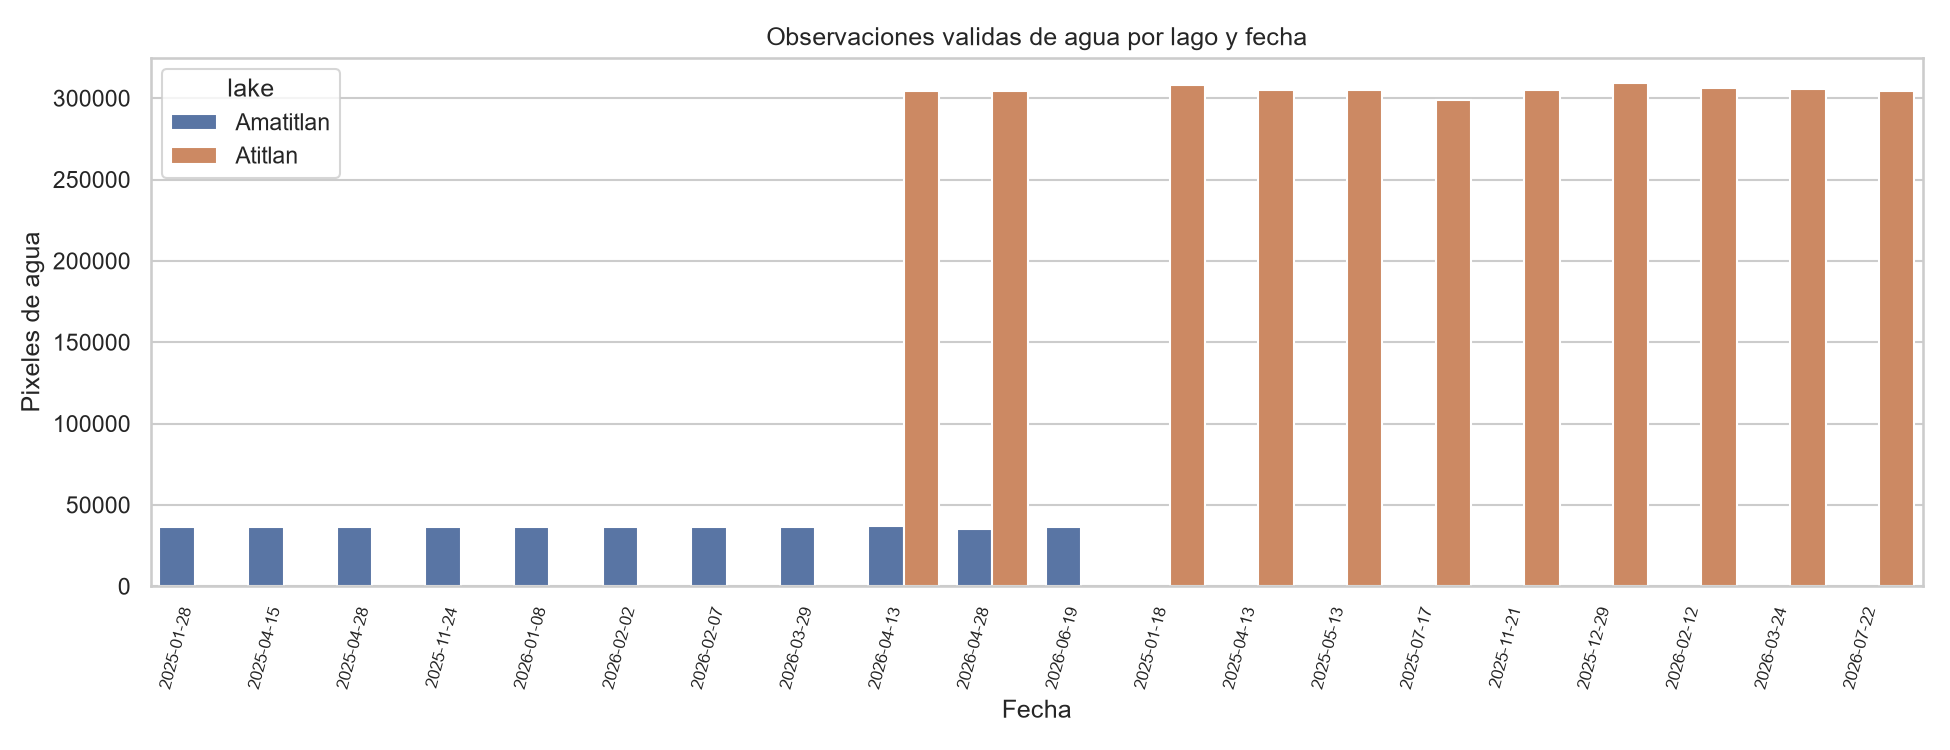

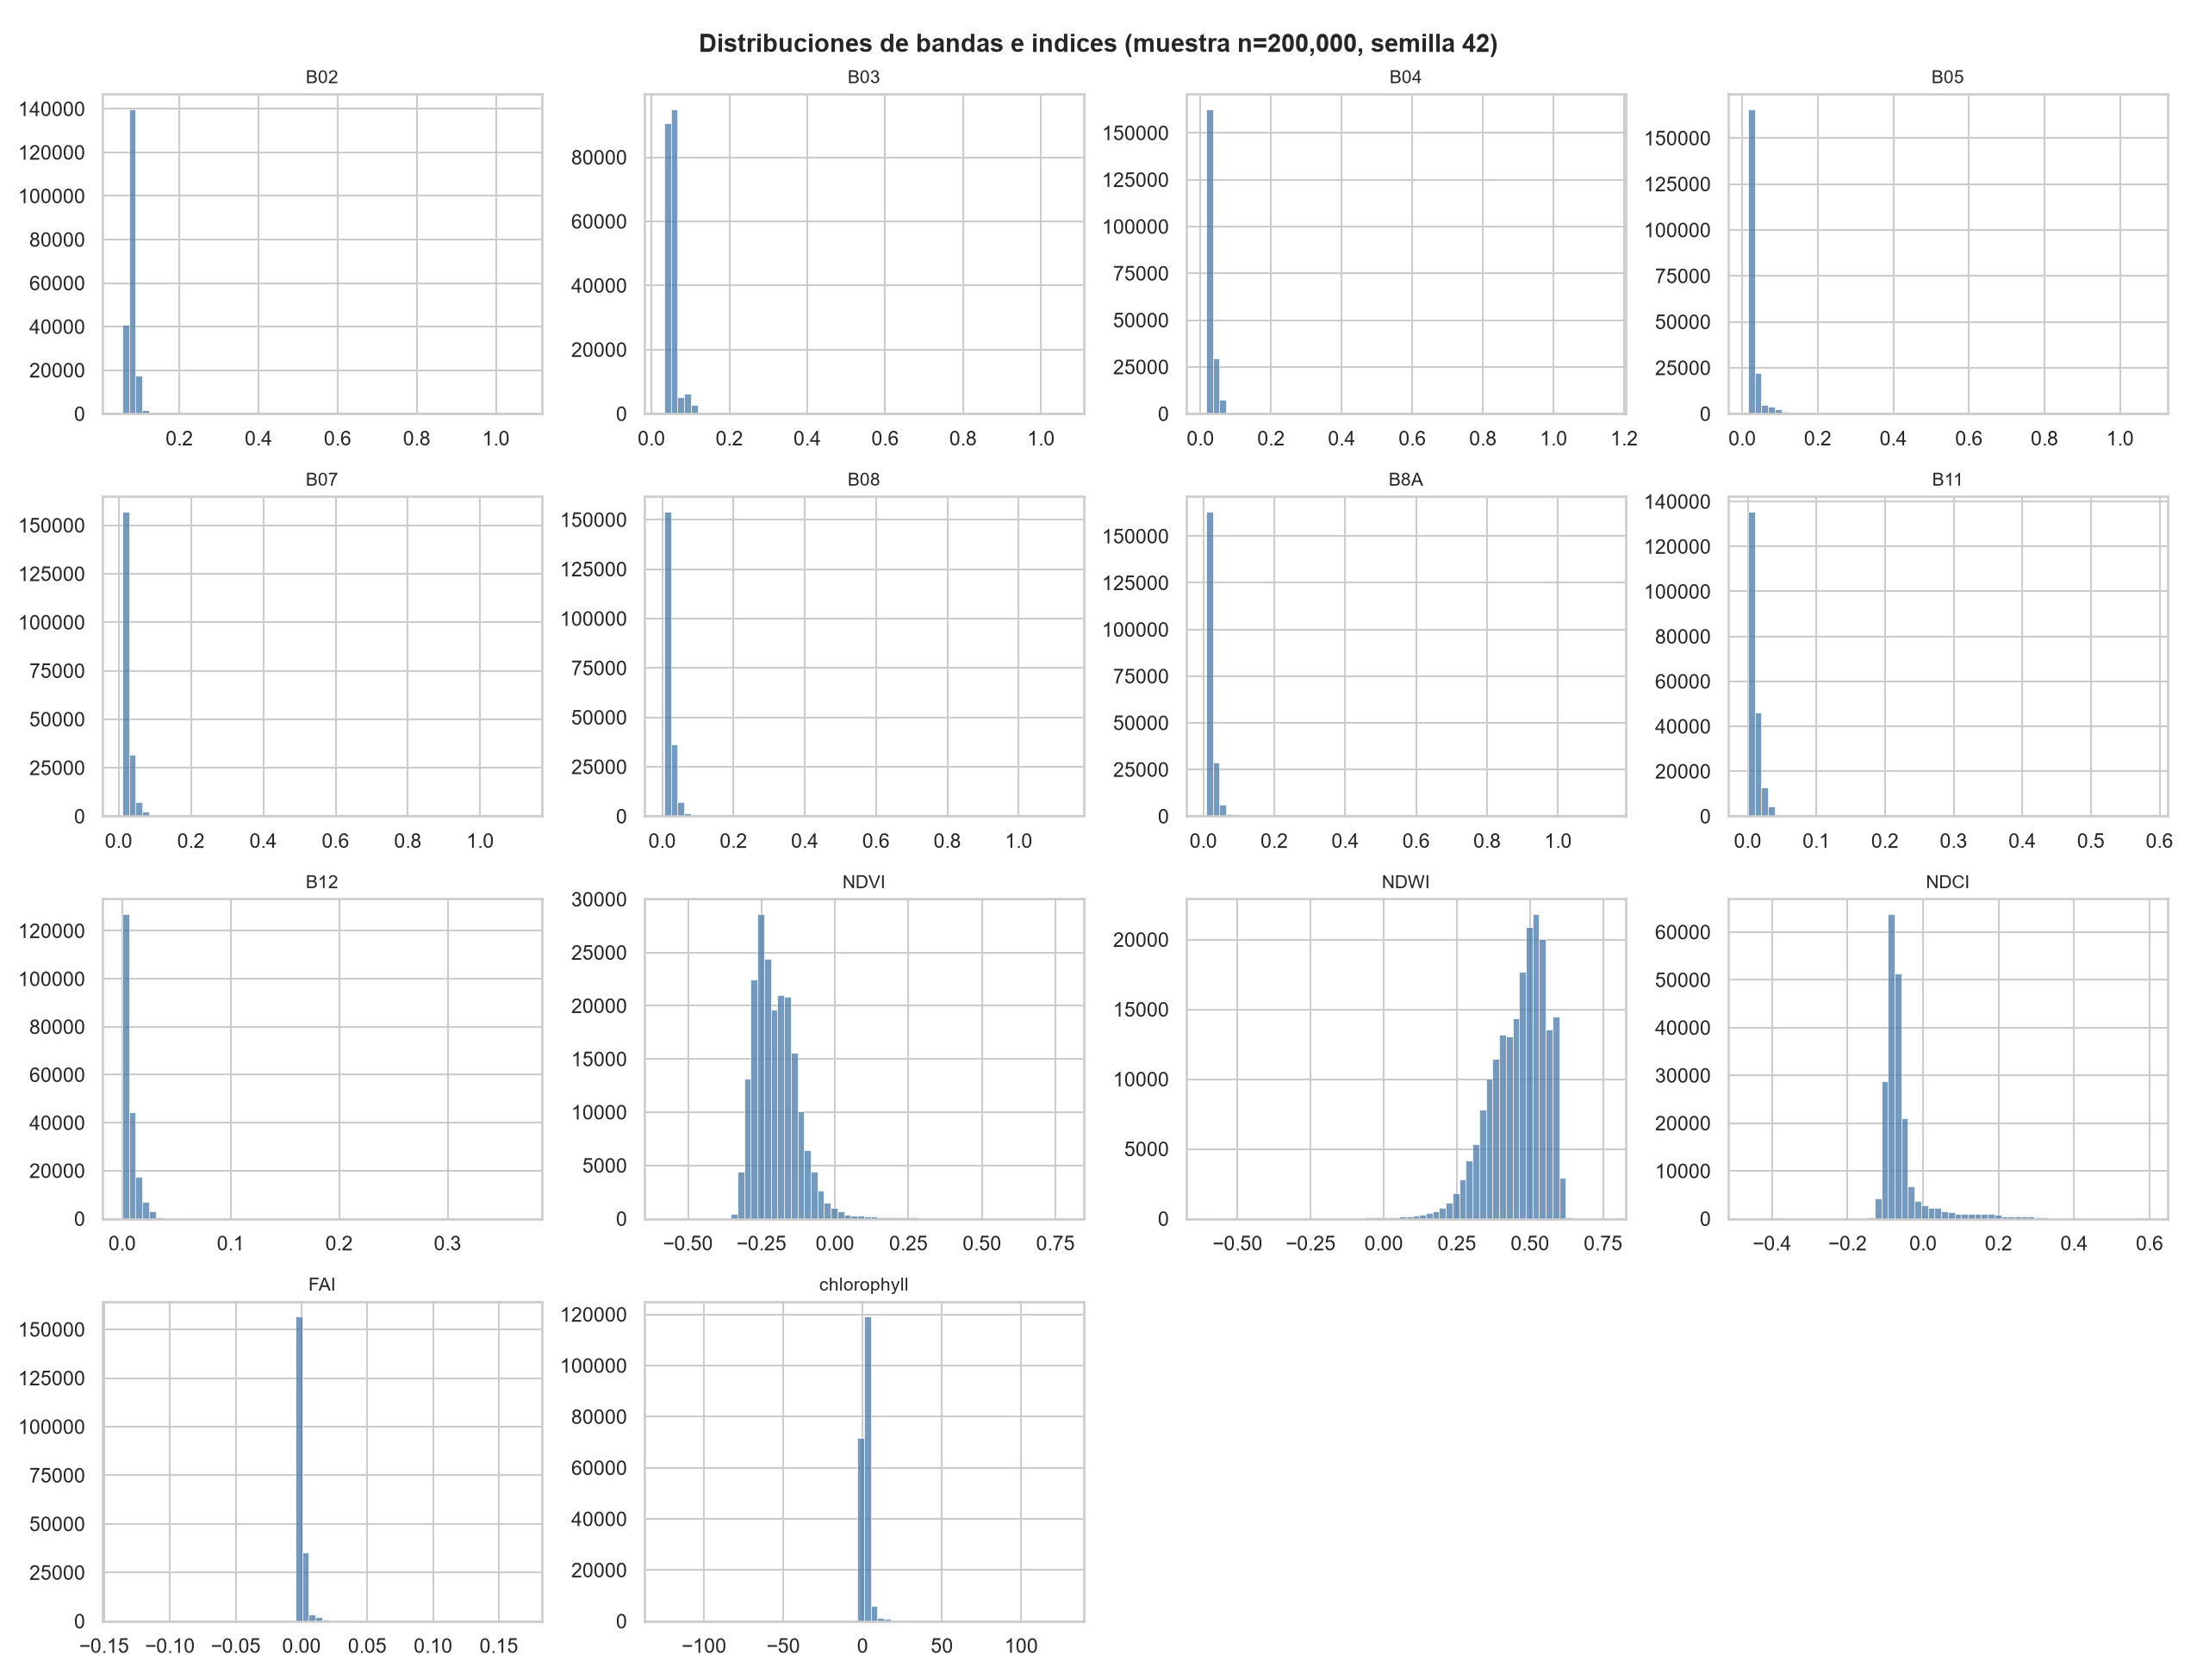

In [7]:
display(Image(filename=str(EDA / "observations_by_lake_date.png")))
display(Image(filename=str(EDA / "feature_distributions.png")))

Distribución de la clorofila-a estimada (dataset completo):
  n                   : 3,756,510
  min                 : -291.1101
  p01                 : -1.8596
  mediana             : 1.3092
  p99                 : 11.3137
  max                 : 135.8611
  negativos           : 560,214
  fuera_calibracion   : 1,513,792

ADVERTENCIA de dominio de calibración [1.0, 60.0] µg/L:
  Fuera de calibración: 1,513,792 (40.30 %)
  Valores negativos   : 560,214 (14.91 %)


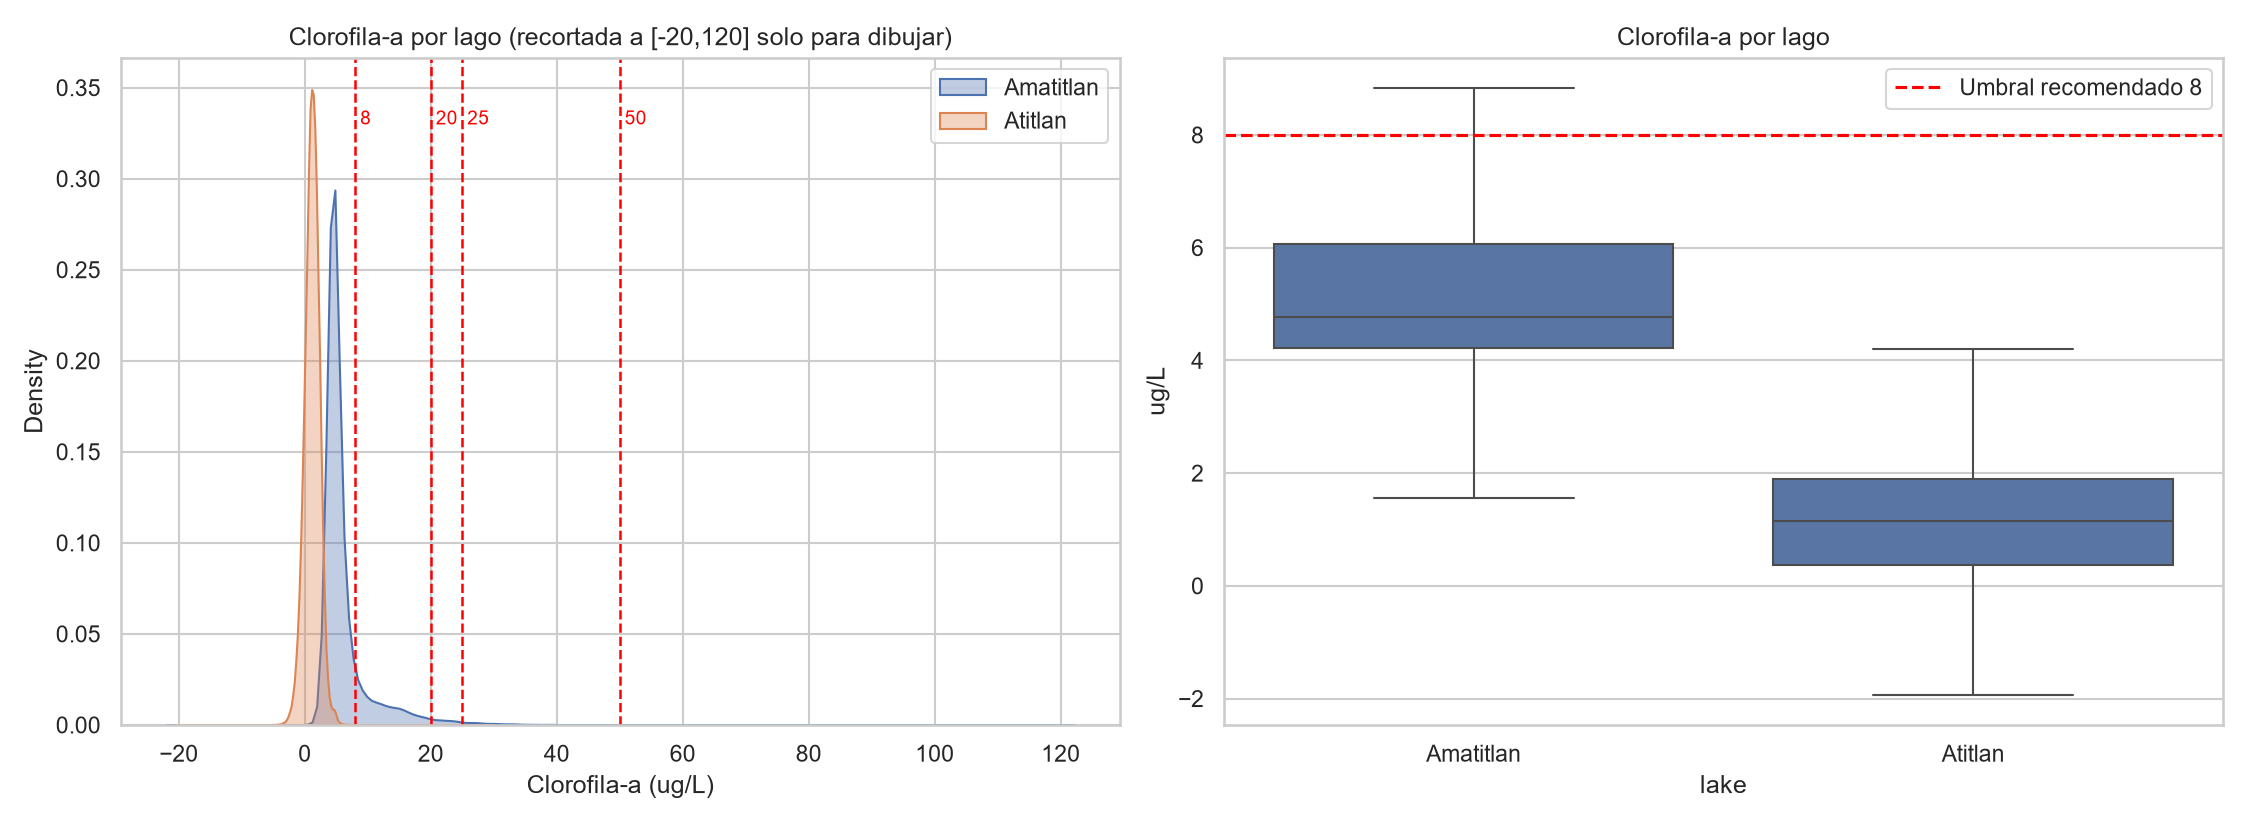

In [8]:
chl_stats = json.load(open(TARGET / "chlorophyll_stats.json", encoding="utf-8"))
print("Distribución de la clorofila-a estimada (dataset completo):")
for k, v in chl_stats.items():
    print(f"  {k:<20}: {v:,.4f}" if isinstance(v, float) else f"  {k:<20}: {v:,}")

print(f"\nADVERTENCIA de dominio de calibración [{CALIB_MIN}, {CALIB_MAX}] µg/L:")
print(f"  Fuera de calibración: {chl_stats['fuera_calibracion']:,} "
      f"({100*chl_stats['fuera_calibracion']/chl_stats['n']:.2f} %)")
print(f"  Valores negativos   : {chl_stats['negativos']:,} "
      f"({100*chl_stats['negativos']/chl_stats['n']:.2f} %)")
display(Image(filename=str(EDA / "chlorophyll_distribution.png")))

> **Los valores negativos de clorofila-a no son concentraciones físicas.** Proceden de
> evaluar el polinomio NDCI → clorofila con NDCI negativo, fuera de su dominio. **No se
> recortaron ni se convirtieron en cero** dentro del dato original: se conservan para
> trazabilidad y se marcan con la columna `fuera_calibracion`, de modo que puedan
> excluirse en cualquier análisis sin alterar el dataset.


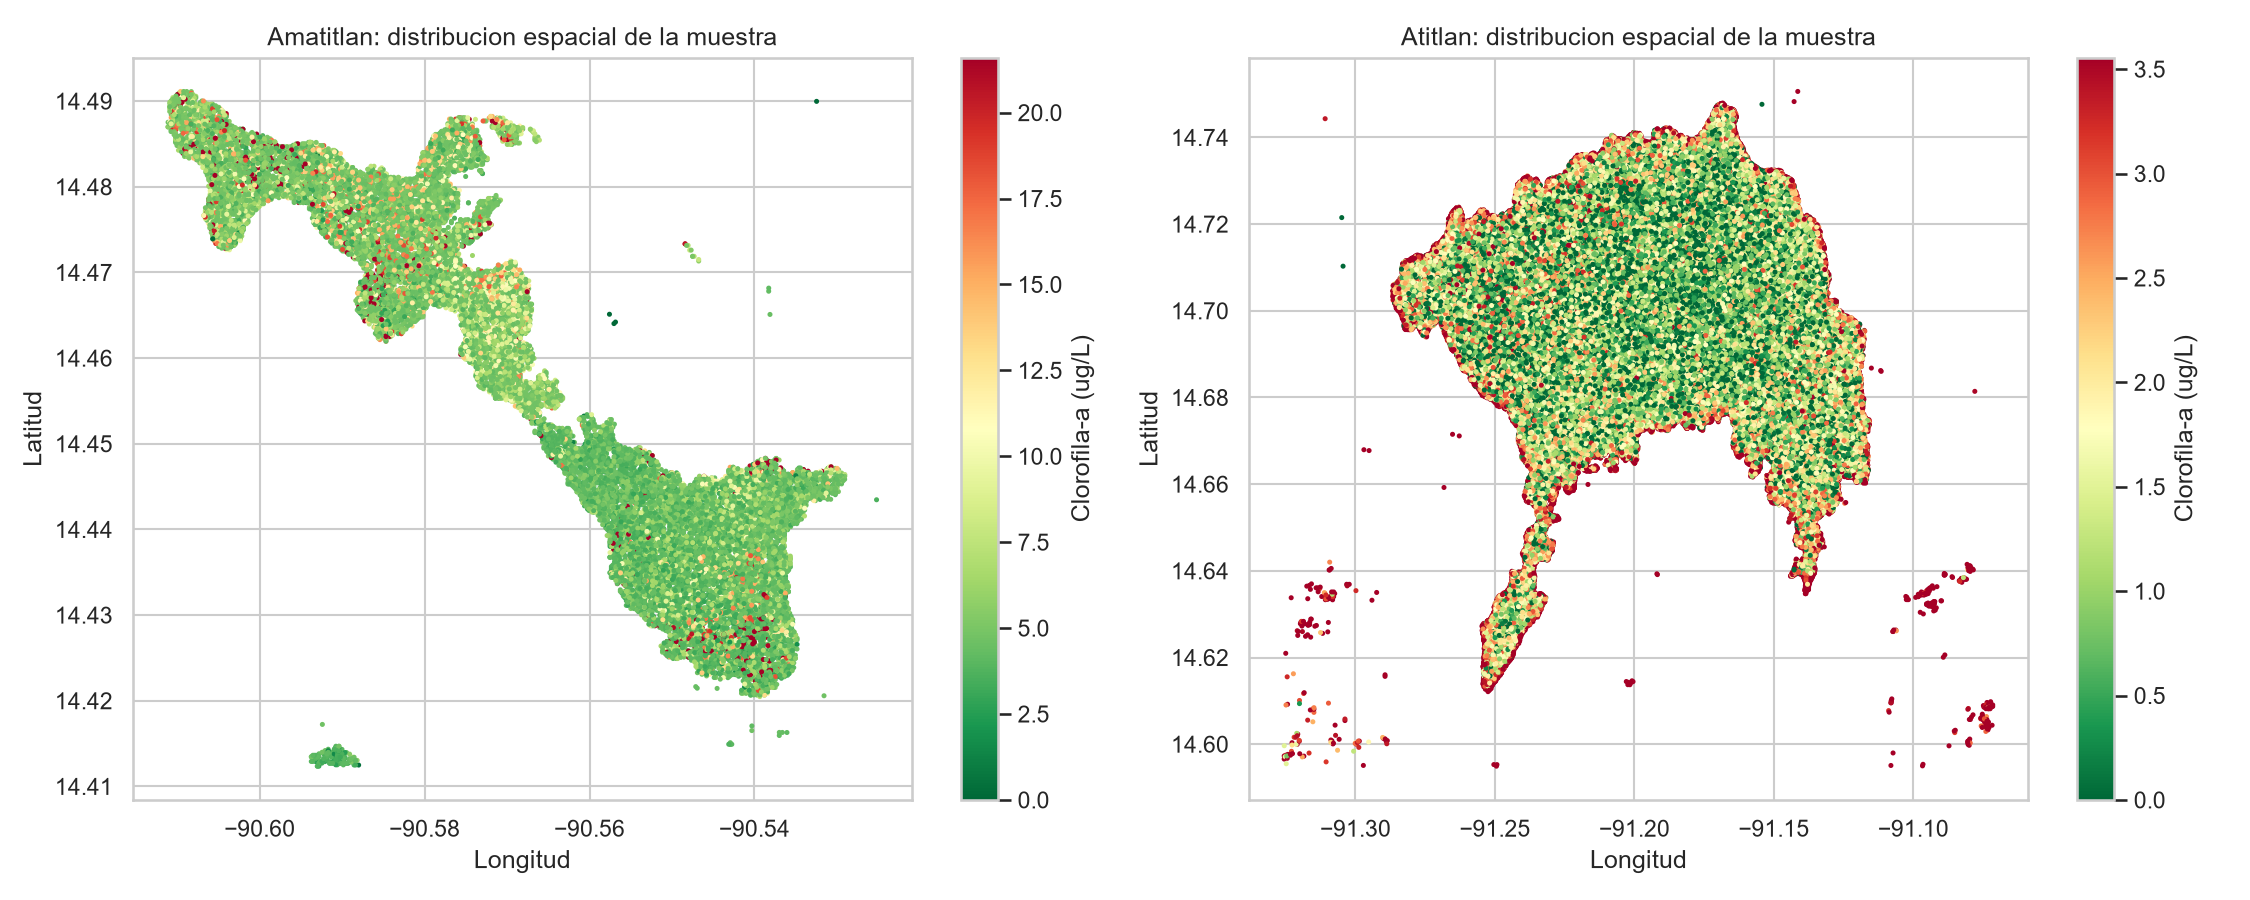

Clorofila-a por lago (muestra determinista):


C:\Users\mjyee\AppData\Local\Temp\ipykernel_12900\4101735042.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(muestra.groupby("lake")["chlorophyll"].describe(


,count,mean,std,min,50%,90%,99%,max
lake,,,,,,,,
Amatitlan,21403.0,6.329,5.332,-19.854,4.762,10.753,26.761,126.830
Atitlan,178597.0,1.114,1.368,-125.095,1.144,2.568,4.130,29.513


In [9]:
# Comparación entre lagos y distribución espacial de la muestra
display(Image(filename=str(EDA / "spatial_sample.png")))
print("Clorofila-a por lago (muestra determinista):")
display(muestra.groupby("lake")["chlorophyll"].describe(
    percentiles=[.5, .9, .99]).round(3))

## 1.6 Decisiones tomadas durante la preparación

| Decisión | Justificación |
|---|---|
| **Escala aplicada una sola vez** | La colección declara `scale = 0.0001, offset = 0`. Se verifica la magnitud antes de transformar, para no dividir dos veces |
| **Una fila por píxel de agua** | El enunciado pide una observación geográfica válida dentro del lago |
| **No se imputan faltantes** | Un píxel sin señal física válida es menos defendible imputado que excluido |
| **Se conservan coordenadas** | Necesarias para reconstrucción espacial y validación agrupada, pero **no como predictores** |
| **Parquet particionado** | 3.75 millones de filas no caben cómodamente en Excel ni en memoria; el particionado por lago y fecha permite leer solo lo necesario |
| **Muestra determinista para figuras** | Semilla 42, reproducible; los conteos siguen calculándose sobre el total |
| **Valores fuera de calibración conservados** | Se marcan, no se eliminan ni se recortan |


---

# Ejercicio 2. Construcción de la variable respuesta

## 2.1 Definición binaria

```
high_cyano_8 = 1  si  clorofila-a >= 8 µg/L
high_cyano_8 = 0  en otro caso
```

> **Prudencia en la interpretación.** La respuesta indica **clorofila-a alta estimada por
> satélite**, no una confirmación in situ de presencia de cianobacterias ni de toxicidad.
> La clorofila mide biomasa fotosintética total: no identifica especies ni toxinas.


## 2.2 Justificación del punto de corte

Se adopta **8 µg/L** porque representa la **transición aproximada hacia la condición
eutrófica**: es la frontera mesotrófico → eutrófico de la clasificación trófica de la
**OECD (1982)**. Operacionaliza «alta presencia» como el punto en que la biomasa algal
deja de ser la propia de un lago equilibrado y el cuerpo de agua entra en un régimen de
exceso de nutrientes.

Los otros tres umbrales **no son alternativas equivalentes**: describen situaciones
ambientales distintas y se conservan como **análisis de sensibilidad**.

| Umbral | Significado ambiental |
|---|---|
| **8 µg/L** *(principal)* | Transición a condición **eutrófica** (OECD 1982) |
| 20 µg/L | **Continuidad con la Parte 1**; dentro de la banda eutrófica (8–25) y del rango de Alerta 1 de la OMS (12–24) |
| 25 µg/L | Transición a condición **hipertrófica** (OECD 1982); coincide con el techo de la Alerta 1 de la OMS (24 µg/L) |
| 50 µg/L | **Escenario extremo**; no aparece como valor de clorofila-a en OECD 1982 ni en las guías de la OMS 2021 |

**El criterio de selección es ambiental.** Que 8 µg/L produzca además más observaciones
positivas es una **consecuencia secundaria** de haber escogido la transición eutrófica, no
el motivo de la elección: la viabilidad estadística se analiza por separado y no
intervino en la definición del umbral.

### Referencias verificadas

- **OECD (1982).** *Eutrophication of Waters: Monitoring, Assessment and Control.* París.
  DOI 10.1787/9789264077980-en. Clasificación por clorofila-a media: oligotrófico < 2.5;
  **mesotrófico 2.5–8**; **eutrófico 8–25**; hipertrófico > 25 µg/L.
- **WHO (2021).** *Guidelines on recreational water quality. Volume 1.* Ginebra. Con
  dominancia de cianobacterias: vigilancia 1–12 µg/L; **Alerta 1: 12–24 µg/L**.
- **Mishra, S. & Mishra, D. R. (2012).** *Normalized difference chlorophyll index…*
  Remote Sensing of Environment **117**, 394–406. DOI 10.1016/j.rse.2011.10.016.
  Introduce el NDCI; calibrado en el rango 1–60 mg/m³.

> **Corrección.** La versión anterior de este cuaderno citaba «Mishra, S. et al. (2019),
> *Applicability of Sentinel-2…*, RSE 232, 111354». Ese DOI corresponde en realidad a
> Hurskainen et al. (2019), *Auxiliary datasets improve accuracy of object-based land
> use/land cover classification in heterogeneous savanna landscapes*, RSE **233**, 111354
> — un artículo de cobertura del suelo, sin relación con calidad del agua. La referencia
> fue sustituida por Mishra & Mishra (2012), que sí sustenta el índice empleado.


## 2.3 Distribución de la respuesta: global, por lago y por fecha

In [10]:
via_global = pd.read_csv(TARGET / "threshold_viability_global.csv")
via_lago = pd.read_csv(TARGET / "threshold_viability_by_lake.csv")
via_fecha = pd.read_csv(TARGET / "threshold_viability_by_date.csv")

print("=== GLOBAL: los cuatro umbrales ===")
display(via_global[["umbral_ug_L", "es_respuesta_principal", "positivos", "negativos",
                    "pct_positivo", "razon_desbalance"]].round(4))

print("=== POR LAGO ===")
display(via_lago[["umbral_ug_L", "lake", "positivos", "negativos",
                  "pct_positivo"]].round(4))

print(f"=== POR FECHA (respuesta principal {TARGET_THRESHOLD_UG_L:.0f} µg/L) ===")
display(via_fecha[via_fecha["umbral_ug_L"] == TARGET_THRESHOLD_UG_L][
    ["lake", "date", "n_total", "positivos", "negativos", "pct_positivo",
     "ambas_clases"]].round(4))

=== GLOBAL: los cuatro umbrales ===


,umbral_ug_L,es_respuesta_principal,positivos,negativos,pct_positivo,razon_desbalance
0,8.0,True,60146,3696364,1.6011,61.4565
1,20.0,False,9832,3746678,0.2617,381.0698
2,25.0,False,5195,3751315,0.1383,722.1011
3,50.0,False,608,3755902,0.0162,6177.4704


=== POR LAGO ===


,umbral_ug_L,lake,positivos,negativos,pct_positivo
0,8.0,Amatitlan,57996,341650,14.5118
1,8.0,Atitlan,2150,3354714,0.0640
2,20.0,Amatitlan,9768,389878,2.4442
3,20.0,Atitlan,64,3356800,0.0019
4,25.0,Amatitlan,5181,394465,1.2964
5,25.0,Atitlan,14,3356850,0.0004
6,50.0,Amatitlan,604,399042,0.1511
7,50.0,Atitlan,4,3356860,0.0001


=== POR FECHA (respuesta principal 8 µg/L) ===


,lake,date,n_total,positivos,negativos,pct_positivo,ambas_clases
0,Amatitlan,2025-01-28,36550,44,36506,0.1204,True
1,Amatitlan,2025-04-15,36184,739,35445,2.0423,True
2,Amatitlan,2025-04-28,36184,4912,31272,13.5751,True
3,Amatitlan,2025-11-24,36434,1029,35405,2.8243,True
4,Amatitlan,2026-01-08,36668,3484,33184,9.5015,True
5,Amatitlan,2026-02-02,36130,6,36124,0.0166,True
6,Amatitlan,2026-02-07,36561,35,36526,0.0957,True
7,Amatitlan,2026-03-29,36594,3906,32688,10.6739,True
8,Amatitlan,2026-04-13,36786,5599,31187,15.2205,True
9,Amatitlan,2026-04-28,34911,15186,19725,43.4992,True


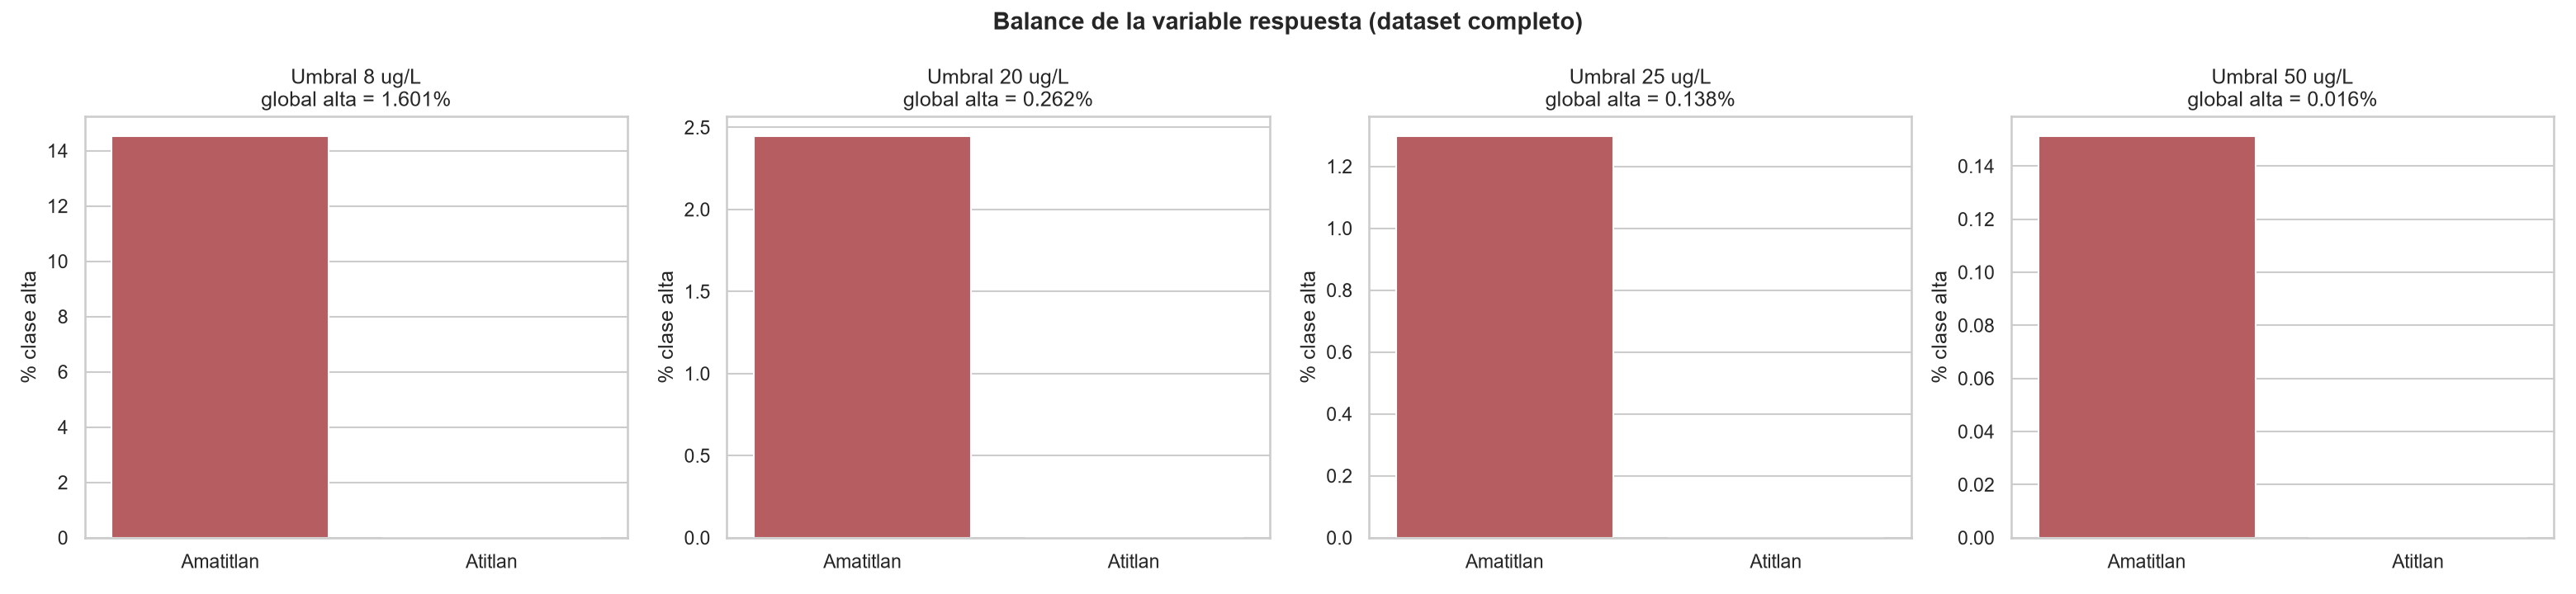

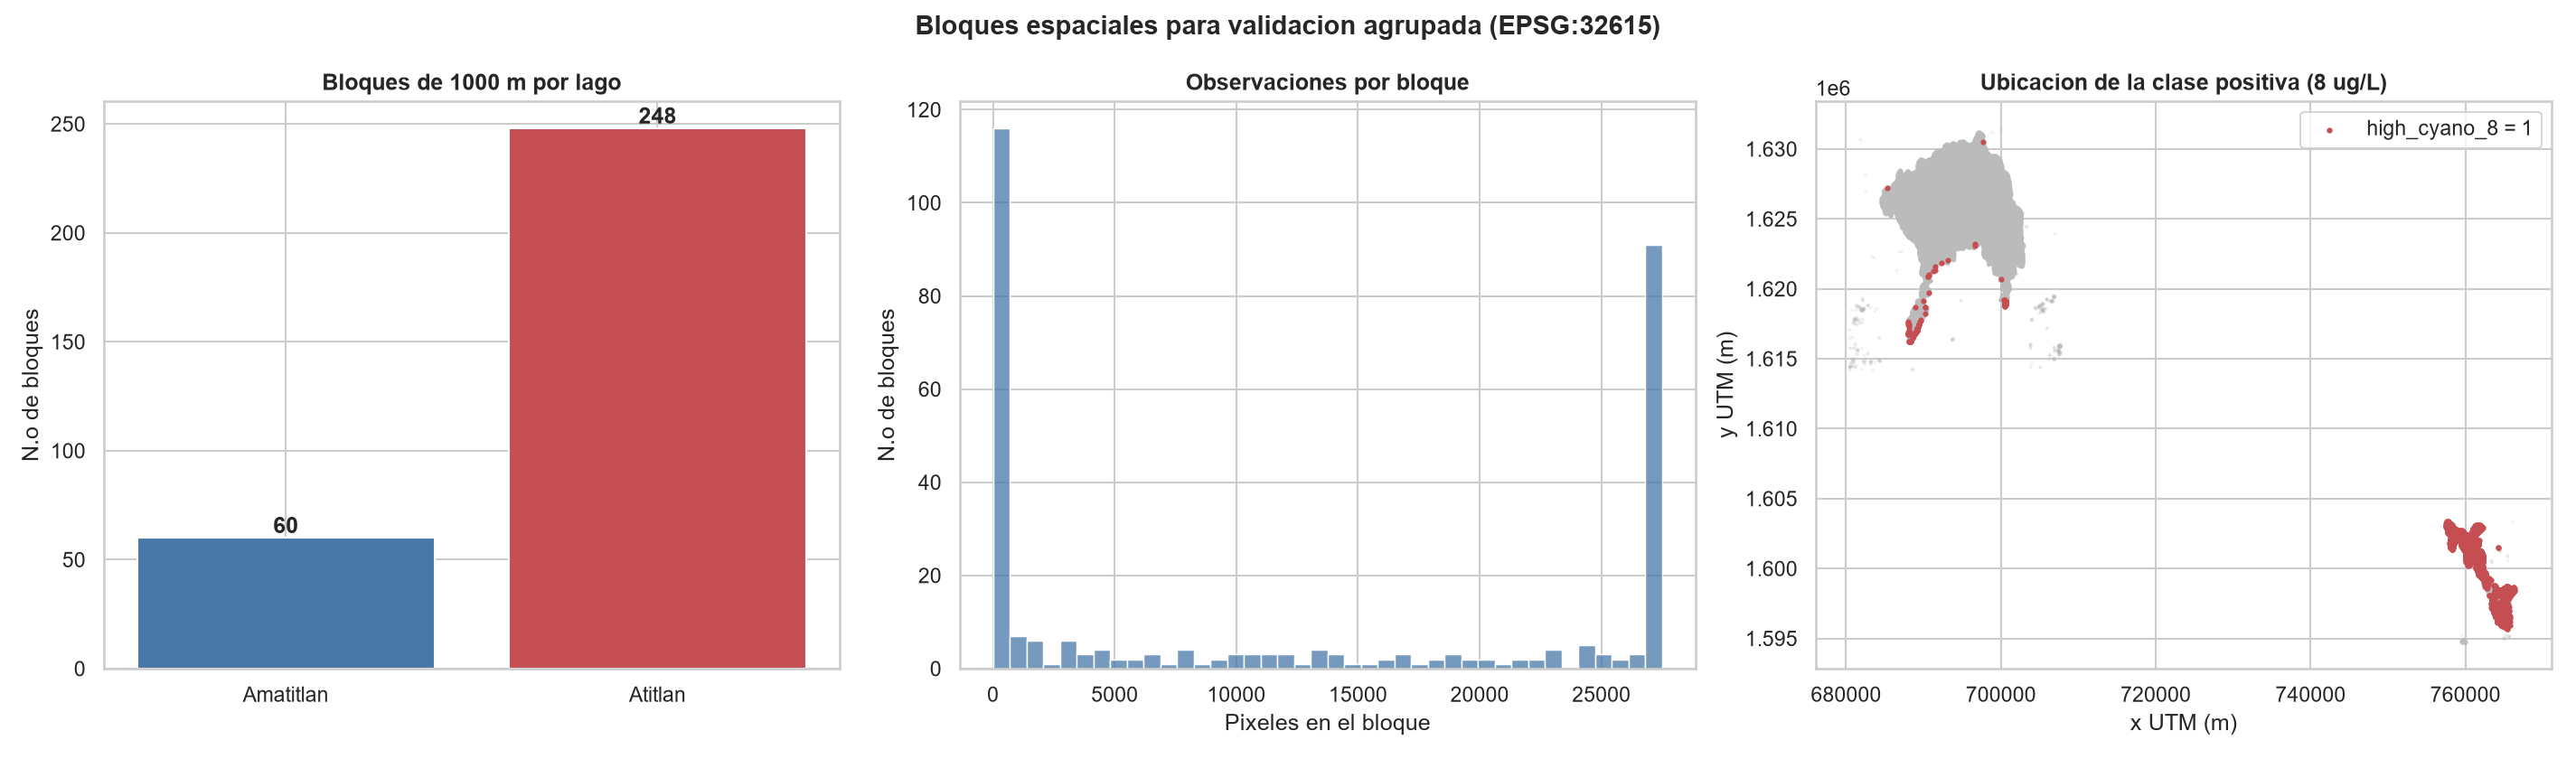

In [11]:
display(Image(filename=str(EDA / "target_balance.png")))
display(Image(filename=str(EDA / "spatial_blocks.png")))

## 2.4 Desbalance de clases y sus consecuencias

In [12]:
principal = via_global[via_global["umbral_ug_L"] == TARGET_THRESHOLD_UG_L].iloc[0]
print(f"RESPUESTA PRINCIPAL: {TARGET_COLUMN} (>= {TARGET_THRESHOLD_UG_L:.0f} µg/L)\n")
print(f"  Positivos : {int(principal['positivos']):,} ({principal['pct_positivo']:.3f} %)")
print(f"  Negativos : {int(principal['negativos']):,}")
print(f"  Desbalance: 1 : {principal['razon_desbalance']:.0f}\n")
print(f"  Fechas con ambas clases : {int(principal['fechas_con_ambas_clases'])}/22")
print(f"  Bloques con positivos   : {int(principal['bloques_con_positivos'])}"
      f"/{int(principal['bloques_totales'])}")
print(f"  N.º efectivo de bloques : {principal['n_efectivo_bloques_positivos']:.1f}")
print(f"  Positivos en 5 bloques  : {principal['pct_positivos_en_top5_bloques']:.1f} %")

acc_trivial = 100 - principal["pct_positivo"]
print(f"\nRIESGO: un clasificador que prediga SIEMPRE la clase mayoritaria")
print(f"        obtendría {acc_trivial:.3f} % de Accuracy sin detectar")
print(f"        ni una sola floración.")

RESPUESTA PRINCIPAL: high_cyano_8 (>= 8 µg/L)

  Positivos : 60,146 (1.601 %)
  Negativos : 3,696,364
  Desbalance: 1 : 61

  Fechas con ambas clases : 22/22
  Bloques con positivos   : 120/308
  N.º efectivo de bloques : 20.5
  Positivos en 5 bloques  : 37.7 %

RIESGO: un clasificador que prediga SIEMPRE la clase mayoritaria
        obtendría 98.399 % de Accuracy sin detectar
        ni una sola floración.


### Consecuencias sobre entrenamiento y evaluación

- **Accuracy engañosa.** Con esta prevalencia, predecir siempre «no hay floración» da una
  exactitud altísima y utilidad nula.
- **Diferencia entre lagos.** Amatitlán tiene una prevalencia ~226 veces mayor que
  Atitlán. Un modelo entrenado en uno verá una frecuencia de clase muy distinta en el otro.
- **Dependencia espacial.** Buena parte de los positivos se concentra en unos pocos
  bloques de 1 km: **no son observaciones independientes**. Sin agrupar por bloque,
  píxeles vecinos casi idénticos caerían a la vez en entrenamiento y prueba, inflando el
  desempeño.
- **Riesgo de folds sin positivos** en validación cruzada agrupada.
- **Colapso a la clase mayoritaria** durante el entrenamiento si no se compensa.

### Recomendaciones para el Ejercicio 4 *(no implementadas todavía)*

- `class_weight="balanced"` en Regresión Logística y Random Forest.
- `scale_pos_weight = n_negativos / n_positivos` en XGBoost.
- Reportar **PR-AUC** además de las métricas obligatorias: con esta prevalencia la curva
  ROC resulta demasiado optimista.
- Reportar **Recall y F1 de la clase positiva** por separado, no solo macro.
- Ajustar el **umbral de decisión** usando solo entrenamiento/validación, nunca prueba.
- **No aplicar SMOTE ni sobremuestreo antes de separar los grupos**: generaría vecinos
  sintéticos de píxeles que después caerían en prueba.
- Conservar intactos los grupos espaciales (`spatial_block_1km`) y temporales (`date`).


### Viabilidad estadística de cada umbral

Un umbral **no** se declara viable por tener un píxel positivo. Los criterios aplicados
son explícitos: ambas clases presentes, positivos repartidos en varias fechas y bloques,
y suficientes grupos positivos para los 5 folds propuestos.


In [13]:
display(via_global[["umbral_ug_L", "positivos", "pct_positivo",
                    "fechas_con_ambas_clases", "bloques_con_positivos",
                    "n_efectivo_bloques_positivos", "viable_stratified_70_30",
                    "viable_groupkfold_bloque", "viable_validacion_temporal",
                    "entrenable_por_lago", "viable_generalizacion_entre_lagos"]].round(3))

print("\nCLAVE: solo 8 µg/L permite entrenar en AMBOS lagos.")
print("Con 20 y 25 µg/L, Atitlán queda con 64 y 14 positivos respectivamente:")
print("insuficiente para entrenar, aunque sí para evaluar.")
print("Con 50 µg/L ningún lago alcanza el mínimo práctico.")

,umbral_ug_L,positivos,pct_positivo,fechas_con_ambas_clases,bloques_con_positivos,n_efectivo_bloques_positivos,viable_stratified_70_30,viable_groupkfold_bloque,viable_validacion_temporal,entrenable_por_lago,viable_generalizacion_entre_lagos
0,8.0,60146,1.601,22,120,20.475,True,True,True,Amatitlan=True;Atitlan=True,True
1,20.0,9832,0.262,15,53,11.933,True,True,True,Amatitlan=True;Atitlan=False,False
2,25.0,5195,0.138,14,42,9.700,True,True,True,Amatitlan=True;Atitlan=False,False
3,50.0,608,0.016,5,13,5.035,True,True,True,Amatitlan=False;Atitlan=False,False



CLAVE: solo 8 µg/L permite entrenar en AMBOS lagos.
Con 20 y 25 µg/L, Atitlán queda con 64 y 14 positivos respectivamente:
insuficiente para entrenar, aunque sí para evaluar.
Con 50 µg/L ningún lago alcanza el mínimo práctico.


## 2.5 Variables que no pueden usarse como predictoras

La cadena de construcción de la respuesta es:

```
B04, B05  →  NDCI  →  chlorophyll  →  high_cyano_8
```

Cualquier variable que participe en esa cadena, directa o indirectamente, produciría
**fuga de información**.


In [14]:
fuga = pd.DataFrame([
    {"variable": v, "motivo": m} for v, m in EXCLUIDAS_POR_FUGA.items()])
display(fuga)

# Comprobación automática: ninguna prohibida puede estar en el conjunto predictor.
respuestas = [f"high_cyano_{int(u)}" for u in UMBRALES_CANDIDATOS]
prohibidas = set(EXCLUIDAS_POR_FUGA) | set(respuestas) | set(COLUMNAS_AUXILIARES)
intrusas = [c for c in PREDICTORES_PRINCIPALES if c in prohibidas]
assert not intrusas, f"FUGA DE INFORMACIÓN: {intrusas}"
print(f"\nVerificado: ninguno de los {len(PREDICTORES_PRINCIPALES)} predictores")
print("principales pertenece a la cadena de la respuesta.")

,variable,motivo
0,B04,"insumo directo de NDCI, que genera la clorofil..."
1,B05,"insumo directo de NDCI, que genera la clorofil..."
2,NDCI,indice del que se deriva la clorofila y por ta...
3,chlorophyll,variable de la que se deriva directamente la r...
4,FAI,utiliza B04; comparte insumo con NDCI (fuga in...
5,NDVI,utiliza B04; se conserva porque el enunciado l...
6,high_cyano_8,es la propia respuesta principal
7,high_cyano_20,es una respuesta candidata (sensibilidad)
8,high_cyano_25,es una respuesta candidata (sensibilidad)
9,high_cyano_50,es una respuesta candidata (sensibilidad)



Verificado: ninguno de los 8 predictores
principales pertenece a la cadena de la respuesta.


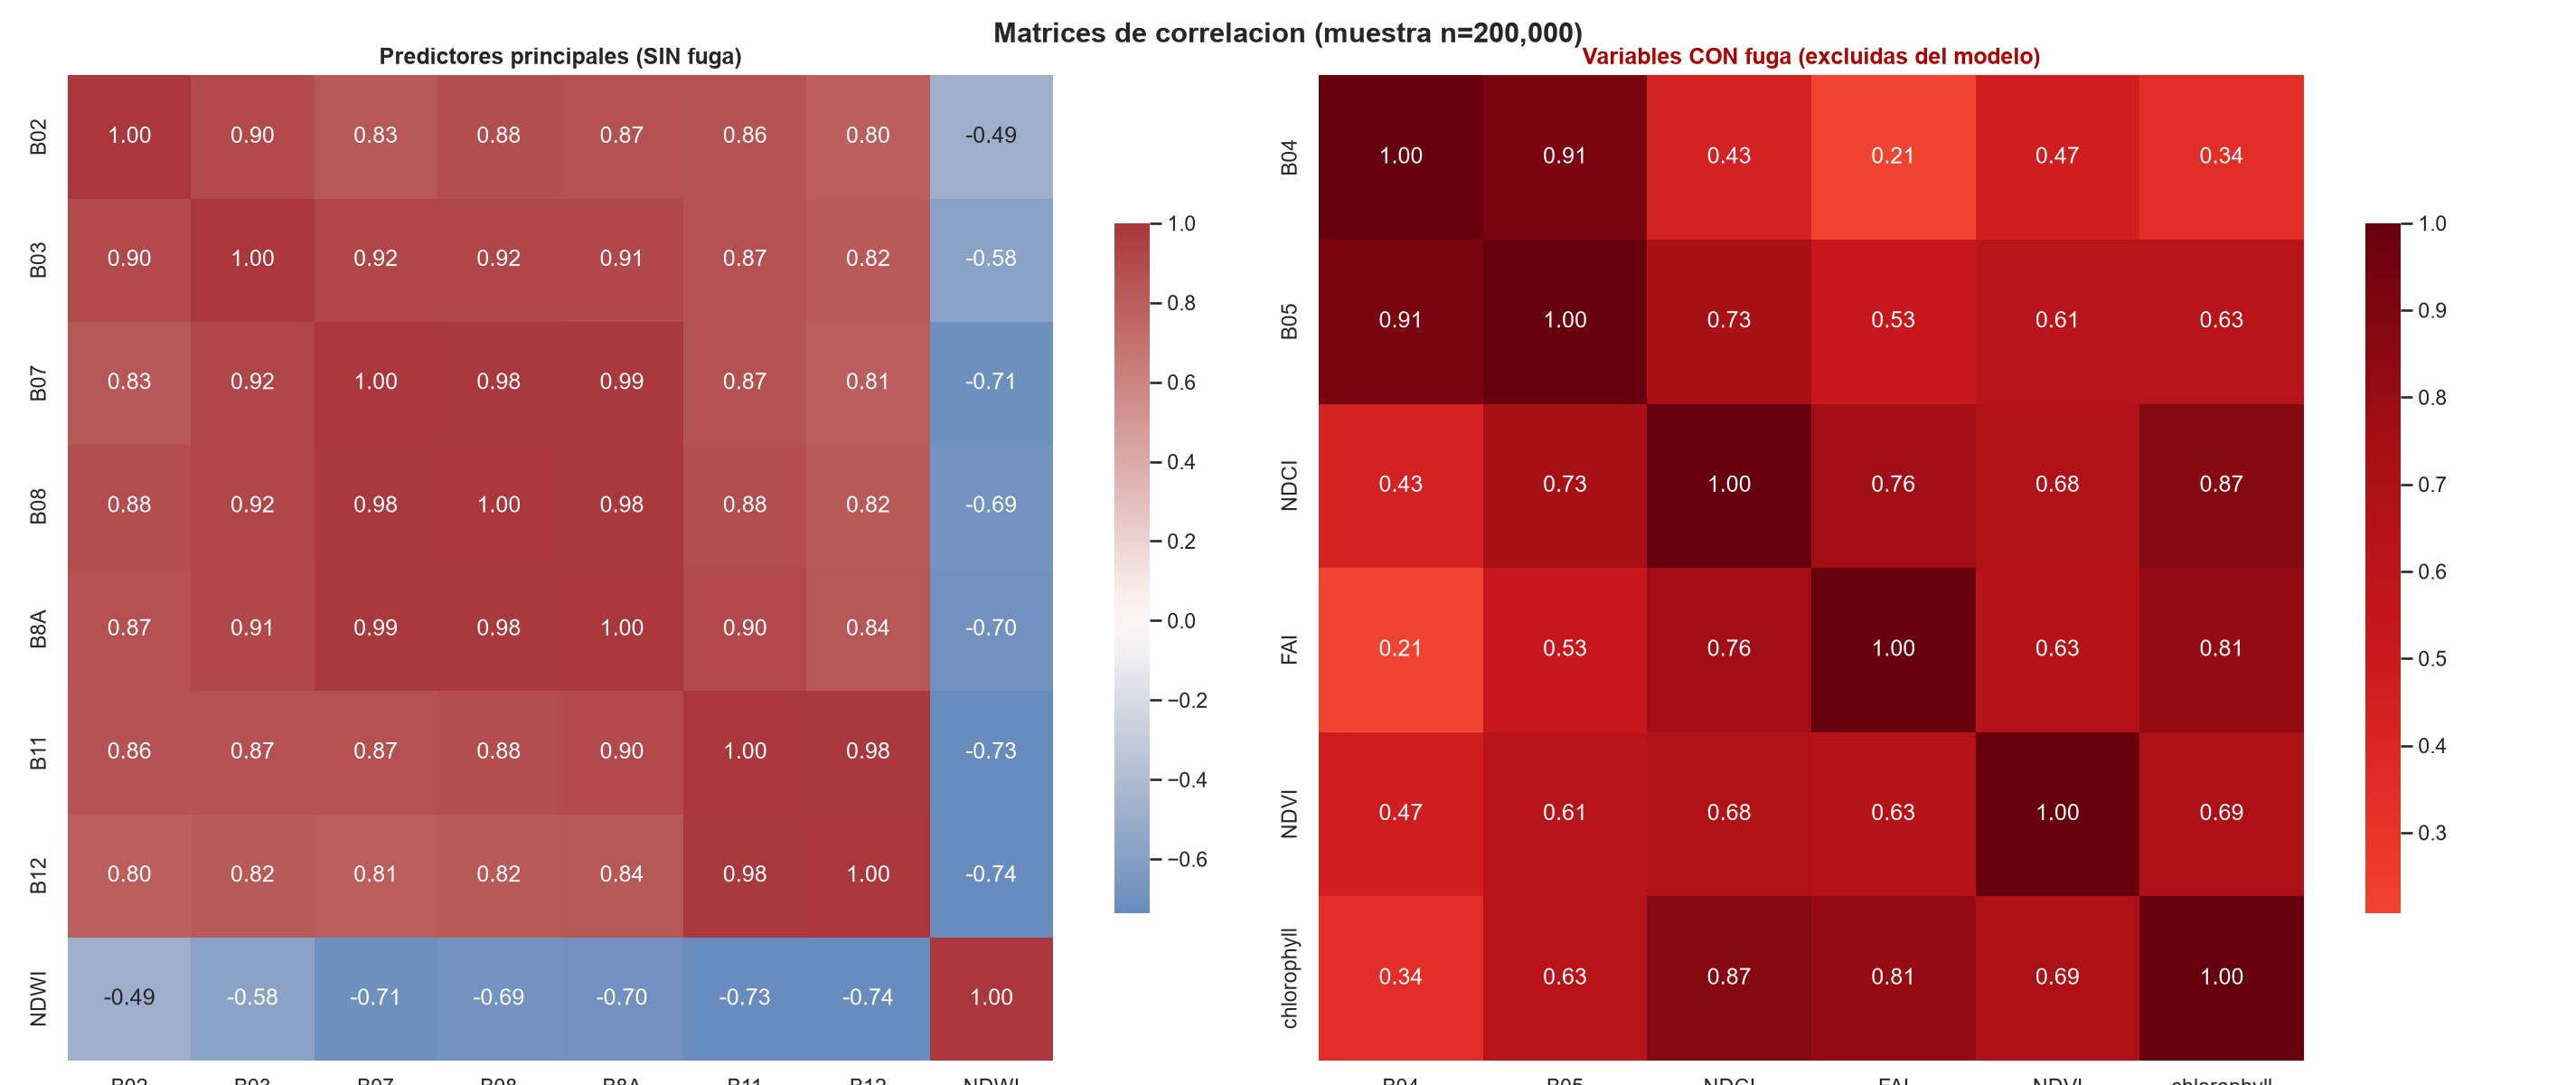

In [15]:
display(Image(filename=str(EDA / "correlation_matrix.png")))

La matriz de la derecha muestra las variables **con fuga**, separadas
visualmente de los predictores permitidos. La correlación entre `NDCI` y `chlorophyll` es
altísima por construcción —la segunda se calcula a partir de la primera— y por eso
**ninguna de las dos puede usarse como predictor**.


---

# Ejercicio 3. Selección y construcción de variables predictoras

## 3.1 Conjunto predictor principal


In [16]:
print("PREDICTORES PRINCIPALES (sin fuga):")
for p in PREDICTORES_PRINCIPALES:
    print(f"  - {p}")
print(f"\nTotal: {len(PREDICTORES_PRINCIPALES)} variables")

print("\nEstadísticas (muestra determinista):")
display(muestra[PREDICTORES_PRINCIPALES].describe(percentiles=[.05, .5, .95]).T.round(4))

PREDICTORES PRINCIPALES (sin fuga):
  - B02
  - B03
  - B07
  - B08
  - B8A
  - B11
  - B12
  - NDWI

Total: 8 variables

Estadísticas (muestra determinista):


,count,mean,std,min,5%,50%,95%,max
B02,200000.0,0.0795,0.0131,0.0558,0.0700,0.0781,0.0925,1.0656
B03,200000.0,0.0535,0.0156,0.0327,0.0436,0.0504,0.0815,1.0586
B07,200000.0,0.0249,0.0170,0.0101,0.0141,0.0212,0.0491,1.1154
B08,200000.0,0.0212,0.0162,0.0057,0.0115,0.0179,0.0426,1.1267
B8A,200000.0,0.0207,0.0158,0.0078,0.0104,0.0174,0.0424,1.1344
B11,200000.0,0.0093,0.0094,0.0005,0.0018,0.0068,0.0249,0.5827
B12,200000.0,0.0066,0.0070,0.0001,0.0010,0.0044,0.0193,0.3685
NDWI,200000.0,0.4589,0.1000,-0.6075,0.2865,0.4780,0.5868,0.7590


## 3.2 Qué representa cada predictor y por qué puede ayudar

| Variable | Tipo | Qué representa y por qué contribuye |
|---|---|---|
| **B02** | Banda espectral (azul, 492 nm) | Sensible a la dispersión por partículas y a la turbidez del agua |
| **B03** | Banda espectral (verde, 560 nm) | Máximo de reflectancia de la biomasa algal: el agua con algas se ve más verde. **No interviene en el NDCI** |
| **B07** | Banda espectral (borde rojo, 783 nm) | Responde a la biomasa vegetal en el agua sin usar B04 ni B05 |
| **B08** | Banda espectral (NIR, 833 nm) | Separa agua de vegetación y detecta natas flotantes en superficie |
| **B8A** | Banda espectral (NIR estrecho, 865 nm) | Complementa a B08 con menor influencia del vapor de agua |
| **B11** | Banda espectral (SWIR1, 1610 nm) | Distingue agua de suelo y de nube; el agua absorbe casi toda la radiación SWIR |
| **B12** | Banda espectral (SWIR2, 2190 nm) | Refuerza la discriminación de agua y detecta contaminación por píxeles mixtos |
| **NDWI** | Índice espectral | (B03 − B08)/(B03 + B08). Caracteriza el estado de la lámina de agua. **No usa B04 ni B05**, así que es independiente de la cadena de la respuesta |

Todos son **bandas espectrales o índices**, no características espaciales: la decisión es
deliberada, para que el modelo aprenda una **señal espectral generalizable** y no la
geografía concreta de estos dos lagos.


## 3.3 Ingeniería de características y variables de agrupación

### Ingeniería propuesta para más adelante *(no aplicada todavía)*

Estas variables podrían construirse en el Ejercicio 4, siempre a partir de bandas
**permitidas**:

- **`rededge_mean` = media de B07 y B8A** — resume la respuesta del borde rojo asociada a
  biomasa, sin tocar B04 ni B05.
- **`nir_green_ratio` = B08 / B03** — contraste entre infrarrojo y verde; sensible a
  material particulado en suspensión.

No se añaden ahora para mantener el conjunto base auditable y comprobar primero el
desempeño de las variables originales.

### Análisis de sensibilidad con NDVI *(etiquetado como riesgo)*

`NDVI` se **conserva en el dataset** porque el enunciado lo exige explícitamente, pero
**no entra en el modelo principal**: usa **B04**, el mismo canal que alimenta el NDCI del
que se deriva la respuesta. Queda preparado como comparación secundaria, claramente
marcada como **riesgo de fuga indirecta**. Si en esa comparación el NDVI apareciera como
variable dominante, sería señal de fuga residual y no de señal ecológica genuina.

### Variables auxiliares de agrupación *(no predictoras)*

| Variable | Uso previsto |
|---|---|
| `spatial_block_1km` | Grupos para `GroupKFold` espacial (Ejercicio 6) |
| `date`, `year`, `month`, `season` | Validación temporal (Ejercicio 6) |
| `lake` | Generalización entre lagos (Ejercicio 7) |
| `row`, `col`, `x_utm`, `y_utm`, `longitude`, `latitude` | Reconstrucción de mapas predictivos (Ejercicio 9) |

Se conservan para agrupar, estratificar y reconstruir, pero **incluirlas como predictores
haría que el modelo memorizara la posición y la fecha** en lugar de aprender el fenómeno.


In [17]:
bloques = pd.read_csv(DATA / "resumen_bloques_1km.csv")
print(f"Bloques espaciales de {BLOQUE_ESPACIAL_M:.0f} m:")
display(bloques.groupby("lake").agg(
    n_bloques=("spatial_block_1km", "nunique"),
    obs_por_bloque_media=("n", "mean"),
    obs_por_bloque_min=("n", "min"),
    obs_por_bloque_max=("n", "max"),
    bloques_con_positivos=("positivos", lambda s: int((s > 0).sum())),
).round(1))

conc = pd.read_csv(TARGET / "threshold_group_concentration.csv")
print("\nConcentración de la clase positiva:")
display(conc[["umbral_ug_L", "positivos_totales", "pct_positivos_en_top5_fechas",
              "pct_positivos_en_top5_bloques", "bloques_positivos",
              "n_efectivo_bloques_positivos"]].round(2))

Bloques espaciales de 1000 m:


,n_bloques,obs_por_bloque_media,obs_por_bloque_min,obs_por_bloque_max,bloques_con_positivos
lake,,,,,
Amatitlan,60,6660.8,1,27498,38
Atitlan,248,13535.7,1,27500,82



Concentración de la clase positiva:


,umbral_ug_L,positivos_totales,pct_positivos_en_top5_fechas,pct_positivos_en_top5_bloques,bloques_positivos,n_efectivo_bloques_positivos
0,8.0,60146,87.55,37.70,120,20.48
1,20.0,9832,96.85,54.38,53,11.93
2,25.0,5195,98.25,57.98,42,9.70
3,50.0,608,100.00,86.18,13,5.03


---

## Estado: Ejercicios 1–3 completados; siguiente paso: Ejercicio 4

### Resumen de lo entregado

| Ejercicio | Estado |
|---|---|
| **1.1–1.6** Preparación de los datos | Completado con 22 escenas reales |
| **2.1–2.5** Variable respuesta | Completado; principal `high_cyano_8` |
| **3.1–3.3** Variables predictoras | Completado; 8 predictores sin fuga |
| 4–10 Modelado y evaluación | **Pendiente** |

### Puntos a tener presentes antes del Ejercicio 4

1. **Desbalance severo**: la clase positiva es ~1.6 % del dataset. Accuracy no sirve como
   métrica principal.
2. **Dependencia espacial**: los positivos están agrupados. Es imprescindible
   `GroupKFold` por `spatial_block_1km`.
3. **Asimetría entre lagos**: con 8 µg/L ambos lagos son entrenables, pero su prevalencia
   difiere en dos órdenes de magnitud.
4. **El estimador satelital muestra concentraciones generalmente menores en Atitlán que
   en Amatitlán durante las fechas estudiadas; sin embargo, una proporción importante de
   sus píxeles cae fuera del dominio de calibración, por lo que los valores absolutos
   requieren validación in situ.**
5. **Sin validación de campo**: el algoritmo reporta MAPE 42.3 % y RMSE relativo 95.8 %,
   calibrado para *Microcystis aeruginosa* sobre datos simulados.

**Este cuaderno no entrena ningún modelo.** El Ejercicio 4 comenzará con Regresión
Logística, Random Forest y Gradient Boosting/XGBoost sobre los 8 predictores definidos.
